In [1]:
!pip install matplotlib

In [2]:
!pip install seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay
)

# Display settings
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [6]:
# Load dataset — latin-1 encoding handles special characters in SMS text
df = pd.read_csv('spam.csv', encoding='latin-1')

# Drop unnamed extra columns (artifacts of the original dataset)
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df

Dataset shape: (5572, 2)
Columns: ['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e bu..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u. U have won the å£750 Pound p...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying somet...


In [7]:
# ── Basic Info ──────────────────────────────────────────────────────────────
print('='*50)
print('DATASET INFO')
print('='*50)
df.info()
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403


Class Distribution:
   ham:  4825  (86.6%)
  spam:   747  (13.4%)


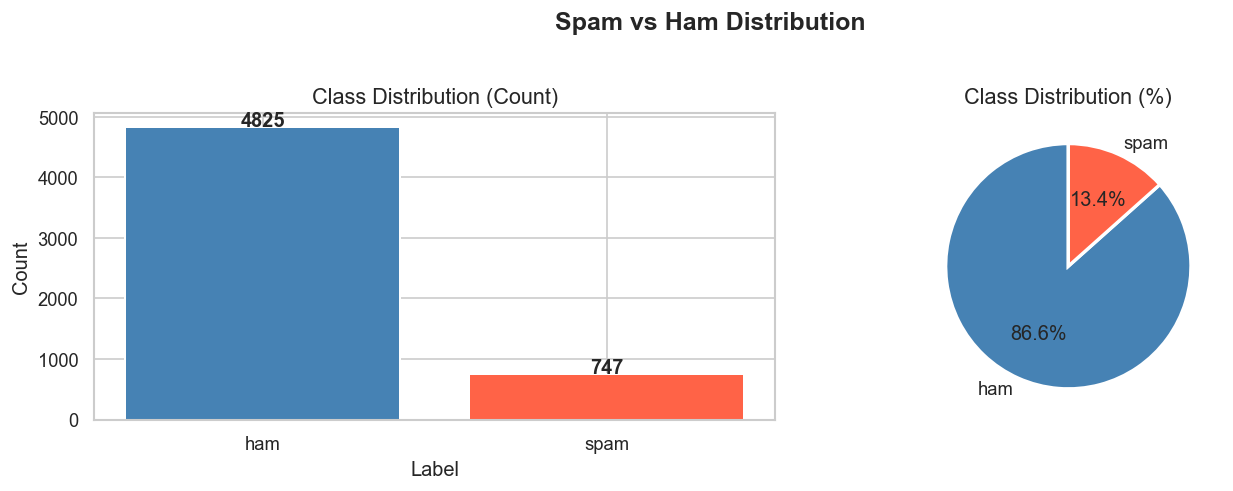

In [8]:
# ── Class Distribution ───────────────────────────────────────────────────────
label_counts = df['label'].value_counts()
label_pct    = df['label'].value_counts(normalize=True) * 100

print('Class Distribution:')
for cls in label_counts.index:
    print(f'  {cls:>4s}: {label_counts[cls]:>5d}  ({label_pct[cls]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(label_counts.index, label_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, (cls, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Spam vs Ham Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Message length stats by class:
      msg_length                                                word_count  \
           count   mean   std   min    25%    50%    75%    max      count   
label                                                                        
ham       4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0     4825.0   
spam       747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0      747.0   

                                                 
       mean   std  min   25%   50%   75%    max  
label                                            
ham    14.2  11.4  1.0   7.0  11.0  19.0  171.0  
spam   23.9   5.8  2.0  22.0  25.0  28.0   35.0  


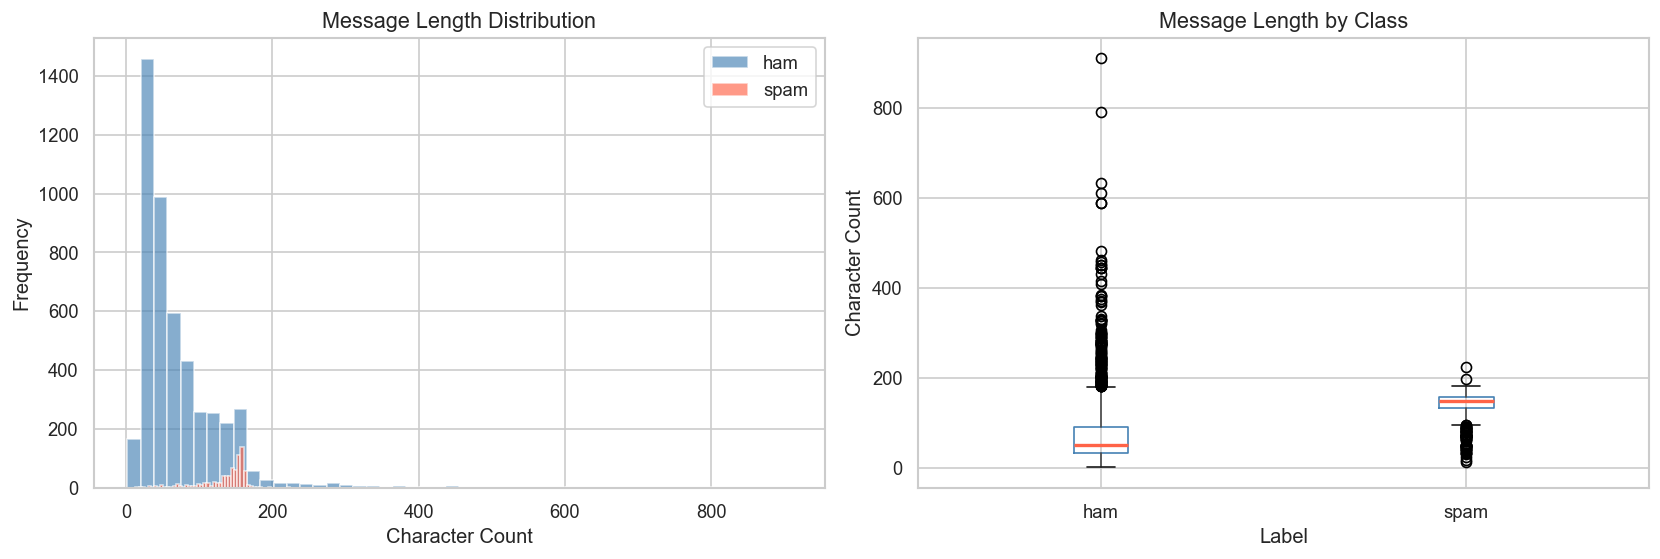

In [9]:
# ── Message Length Analysis ──────────────────────────────────────────────────
df['msg_length']    = df['message'].apply(len)
df['word_count']    = df['message'].apply(lambda x: len(x.split()))
df['char_no_space'] = df['message'].apply(lambda x: len(x.replace(' ', '')))

print('Message length stats by class:')
print(df.groupby('label')[['msg_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('ham', 'steelblue'), ('spam', 'tomato')]:
    subset = df[df['label'] == label]['msg_length']
    axes[0].hist(subset, bins=50, alpha=0.65, label=label, color=color, edgecolor='white')
axes[0].set_title('Message Length Distribution', fontsize=13)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df.boxplot(column='msg_length', by='label', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Message Length by Class', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Character Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [10]:
# ── Sample Messages ──────────────────────────────────────────────────────────
print('Sample HAM messages:')
for msg in df[df['label'] == 'ham']['message'].sample(3, random_state=42).values:
    print(f'  → {msg[:120]}')

print()
print('Sample SPAM messages:')
for msg in df[df['label'] == 'spam']['message'].sample(3, random_state=42).values:
    print(f'  → {msg[:120]}')

Sample HAM messages:
  → I am late,so call you tomorrow morning.take care sweet dreams....u and me...ummifying...bye.
  → U r too much close to my heart. If u go away i will be shattered. Plz stay with me.
  → Wait  &lt;#&gt;  min..

Sample SPAM messages:
  → Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 
  → This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! O
  → Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just å£1.50 per wk 


In [11]:
# ── Remove duplicates ────────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='message').reset_index(drop=True)
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

# ── Encode labels ────────────────────────────────────────────────────────────
# ham → 0, spam → 1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_text = df['message']
y      = df['label_enc']

# ── Train / Test Split (80/20) ───────────────────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {len(X_train_text)}')
print(f'Test  size : {len(X_test_text)}')

# ── TF-IDF Vectorization ─────────────────────────────────────────────────────
# Fit ONLY on training data to prevent data leakage
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                        sublinear_tf=True, strip_accents='unicode',
                        analyzer='word', min_df=2)

X_train = tfidf.fit_transform(X_train_text)   # fit + transform on train
X_test  = tfidf.transform(X_test_text)        # transform only on test

print(f'\nTF-IDF feature matrix: {X_train.shape}')

# ── StandardScaler (on dense features if needed) ────────────────────────────
# For tree-based models we keep sparse TF-IDF as-is.
# For distance-based models (KNN, SVM) we use the TF-IDF directly (already normalised).
# Scaler is fitted ONLY on training data.
scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse matrices
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Preprocessing complete — no data leakage!')

Removed 403 duplicate rows. Remaining: 5169
Label mapping: {'ham': np.int64(0), 'spam': np.int64(1)}
Train size : 4135
Test  size : 1034

TF-IDF feature matrix: (4135, 5000)
✅ Preprocessing complete — no data leakage!


In [12]:
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'            : MultinomialNB(),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'      : GradientBoostingClassifier(random_state=42),
    'AdaBoost'               : AdaBoostClassifier(random_state=42),
    'Linear SVC'             : LinearSVC(max_iter=2000, random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results = []

for name, model in models.items():
    # Naive Bayes needs non-negative input → use raw TF-IDF (already non-neg)
    # LinearSVC / KNN → scaled is fine too (with_mean=False preserves non-neg)
    X_tr = X_train if name == 'Naive Bayes' else X_train_scaled
    X_te = X_test  if name == 'Naive Bayes' else X_test_scaled

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1 Score'  : f1_score(y_test, y_pred),
    })
    print(f'{name:<25} | Acc: {results[-1]["Accuracy"]:.4f} | F1: {results[-1]["F1 Score"]:.4f}')

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print()
results_df

Logistic Regression       | Acc: 0.9807 | F1: 0.9194
Naive Bayes               | Acc: 0.9671 | F1: 0.8509
Decision Tree             | Acc: 0.9613 | F1: 0.8450
Random Forest             | Acc: 0.9758 | F1: 0.8954
Gradient Boosting         | Acc: 0.9710 | F1: 0.8739
AdaBoost                  | Acc: 0.9449 | F1: 0.7532
Linear SVC                | Acc: 0.9768 | F1: 0.9016
K-Nearest Neighbors       | Acc: 0.9072 | F1: 0.4217



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.980658,0.974359,0.870229,0.919355
1,Linear SVC,0.976789,0.973451,0.839695,0.901639
2,Random Forest,0.975822,0.990741,0.816794,0.895397
3,Gradient Boosting,0.970986,0.971963,0.793893,0.873950
4,Naive Bayes,0.967118,1.000000,0.740458,0.850877
5,Decision Tree,0.961315,0.858268,0.832061,0.844961
6,AdaBoost,0.944874,0.870000,0.664122,0.753247
7,K-Nearest Neighbors,0.907157,1.000000,0.267176,0.421687


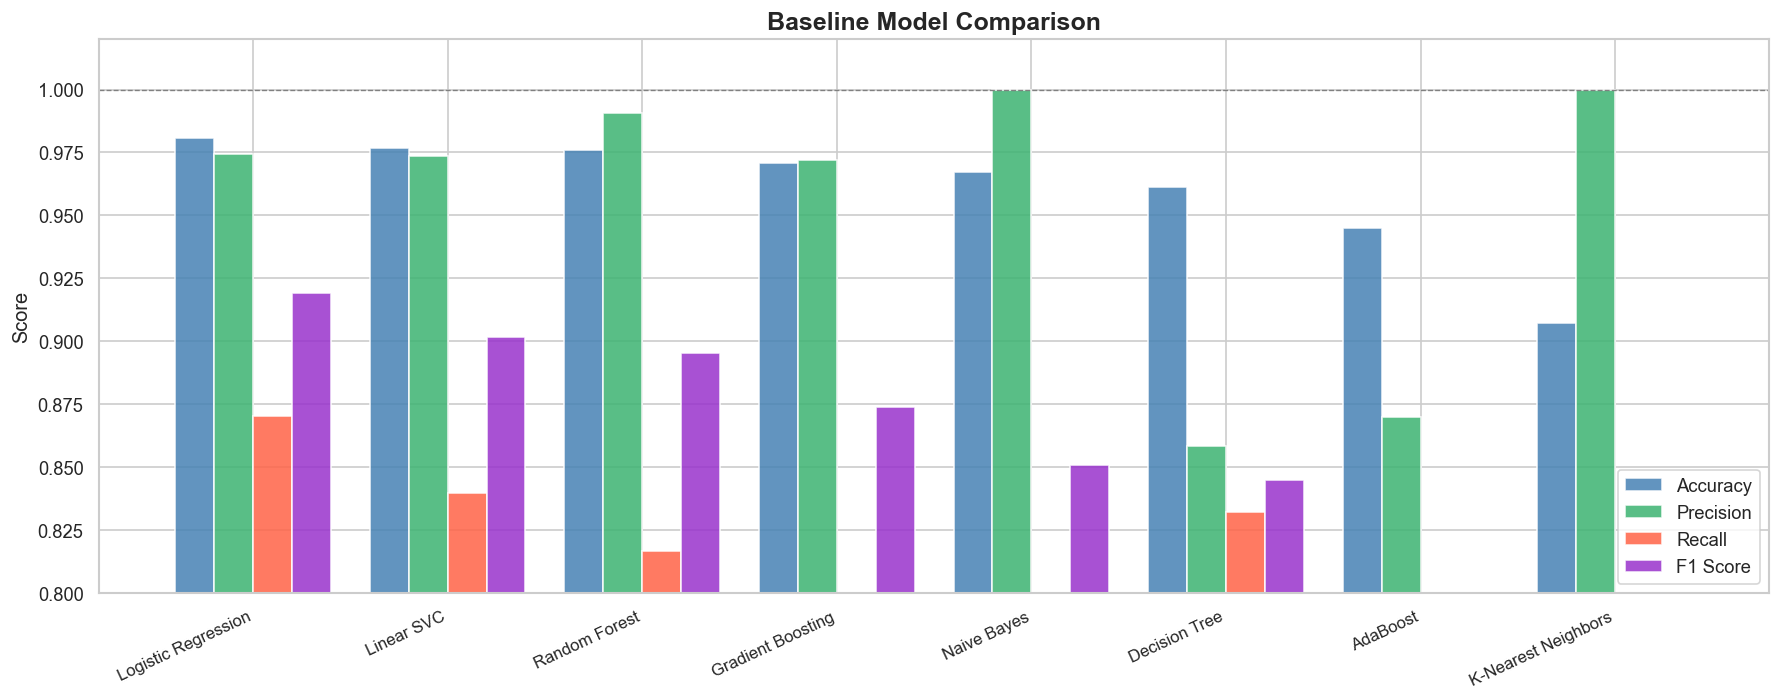

In [13]:
# ── Visual comparison ────────────────────────────────────────────────────────
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x         = np.arange(len(results_df))
width     = 0.2
colors    = ['steelblue', 'mediumseagreen', 'tomato', 'darkorchid']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

Top 3 models selected for CV: ['Logistic Regression', 'Linear SVC', 'Random Forest']
Logistic Regression       | CV F1: 0.9097 ± 0.0213  | Folds: [0.9128 0.9286 0.9082 0.9286 0.8705]
Linear SVC                | CV F1: 0.9057 ± 0.0127  | Folds: [0.8969 0.9231 0.9091 0.9128 0.8866]
Random Forest             | CV F1: 0.8903 ± 0.0252  | Folds: [0.8817 0.8936 0.9223 0.9062 0.8478]


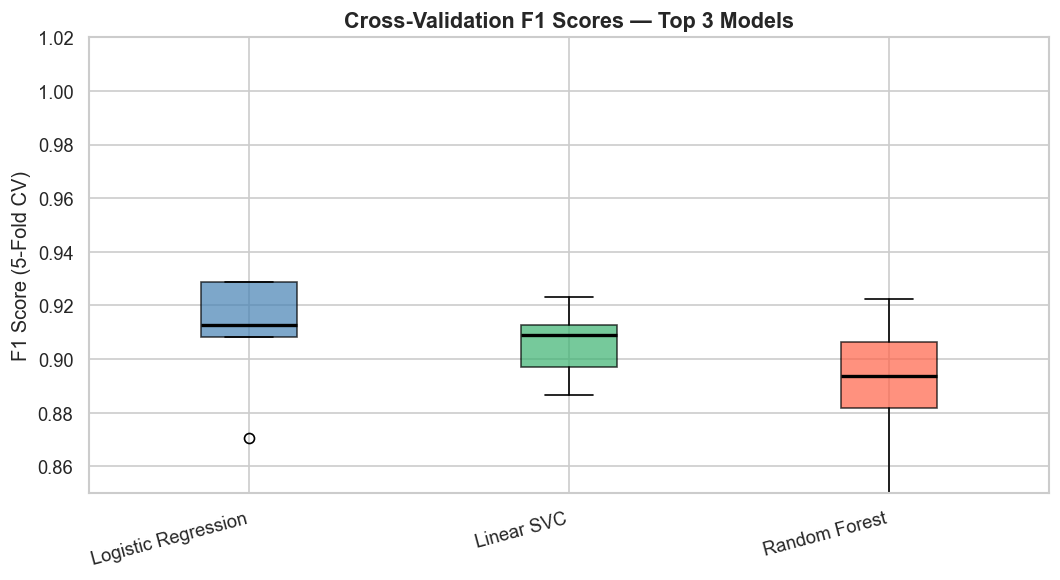

In [14]:
top3_names = results_df['Model'].head(3).tolist()
print(f'Top 3 models selected for CV: {top3_names}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name in top3_names:
    model = models[name]
    X_cv  = X_train if name == 'Naive Bayes' else X_train_scaled

    scores = cross_val_score(model, X_cv, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} | CV F1: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'| Folds: {np.round(scores, 4)}')

# ── Box plot of CV scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(cv_results.values(), patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors_bp = ['steelblue', 'mediumseagreen', 'tomato']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cv_results.keys(), rotation=15, ha='right')
ax.set_ylabel('F1 Score (5-Fold CV)')
ax.set_title('Cross-Validation F1 Scores — Top 3 Models', fontsize=13, fontweight='bold')
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

In [15]:
# ── Tune Random Forest (adjust top1_name to whichever model is best) ─────────
best_model_name = results_df.iloc[0]['Model']
print(f'Tuning: {best_model_name}')

# ── Parameter grids per model ─────────────────────────────────────────────────
param_grids = {
    'Random Forest': {
        'n_estimators'     : [100, 200],
        'max_depth'        : [None, 20, 40],
        'min_samples_split': [2, 5],
        'class_weight'     : [None, 'balanced'],
    },
    'Logistic Regression': {
        'C'          : [0.01, 0.1, 1, 10, 100],
        'penalty'    : ['l2'],
        'solver'     : ['lbfgs', 'liblinear'],
        'class_weight': [None, 'balanced'],
    },
    'Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'   : [3, 5],
    },
    'Linear SVC': {
        'C'           : [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.5, 1.0, 1.5],
    },
    'Decision Tree': {
        'max_depth'        : [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'class_weight'     : [None, 'balanced'],
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 11],
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'cosine'],
    },
}

base_model = models[best_model_name]
param_grid = param_grids.get(best_model_name, {})

X_tune = X_train if best_model_name == 'Naive Bayes' else X_train_scaled

grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,
)

grid_search.fit(X_tune, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Tuning: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters : {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 0.9246


In [16]:
best_model = grid_search.best_estimator_

X_te_final = X_test if best_model_name == 'Naive Bayes' else X_test_scaled
y_pred_best = best_model.predict(X_te_final)

# ── Metrics ──────────────────────────────────────────────────────────────────
print('='*55)
print(f'  FINAL EVALUATION — {best_model_name}')
print('='*55)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_best):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['ham', 'spam']))

  FINAL EVALUATION — Logistic Regression
  Accuracy  : 0.9826
  Precision : 0.9829
  Recall    : 0.8779
  F1 Score  : 0.9274

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.98      0.88      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



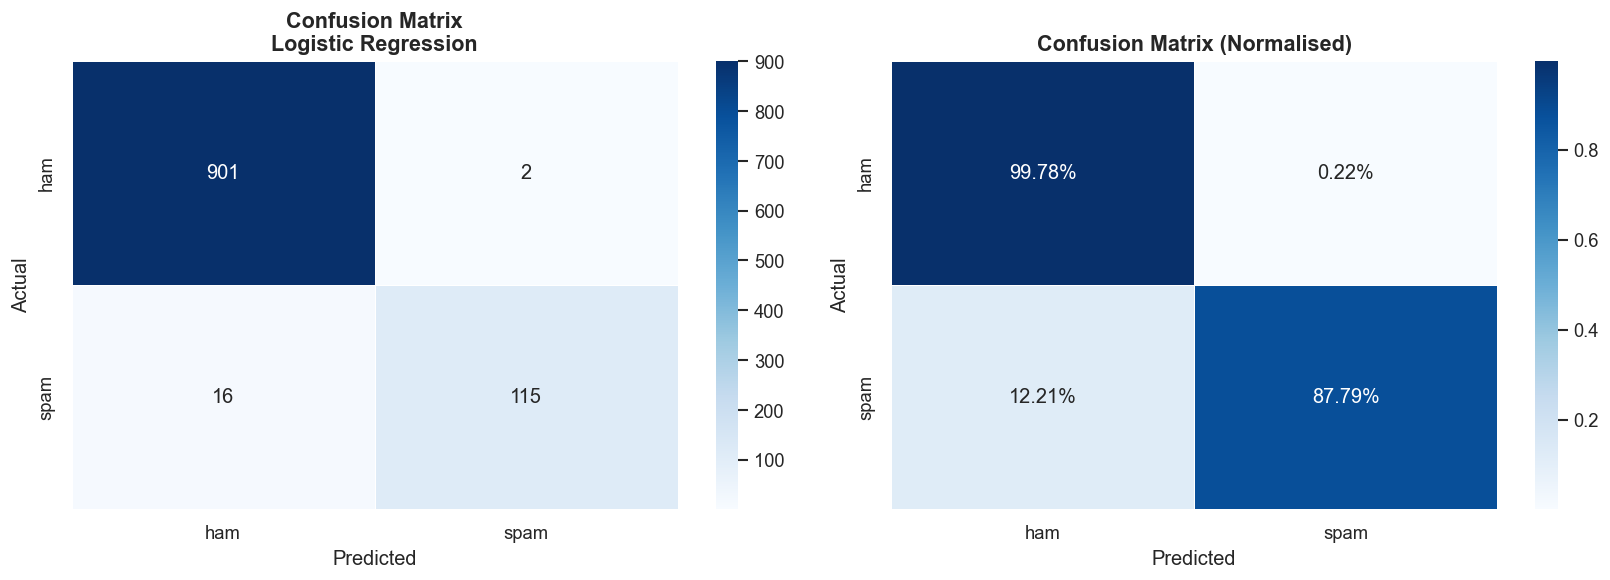

In [17]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

ROC-AUC Score: 0.9930


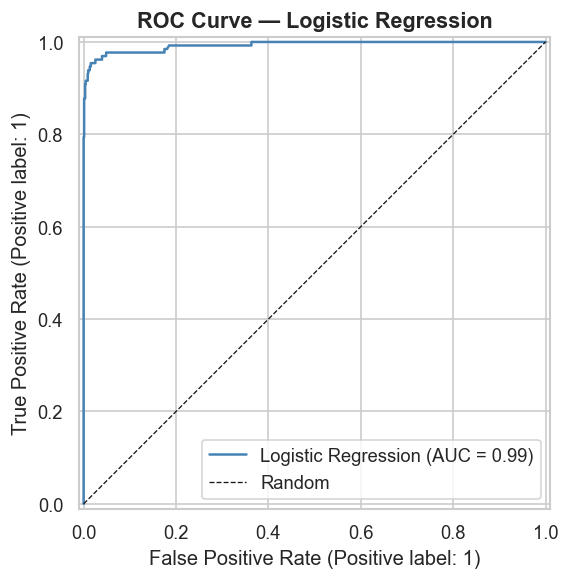

In [18]:
# ── ROC Curve (if model supports predict_proba) ───────────────────────────────
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_te_final)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f'ROC-AUC Score: {roc_auc:.4f}')

    fig, ax = plt.subplots(figsize=(7, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                     name=best_model_name, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
    ax.set_title(f'ROC Curve — {best_model_name}', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not support predict_proba — ROC curve skipped.')
    print('(LinearSVC uses decision_function for ROC if needed)')

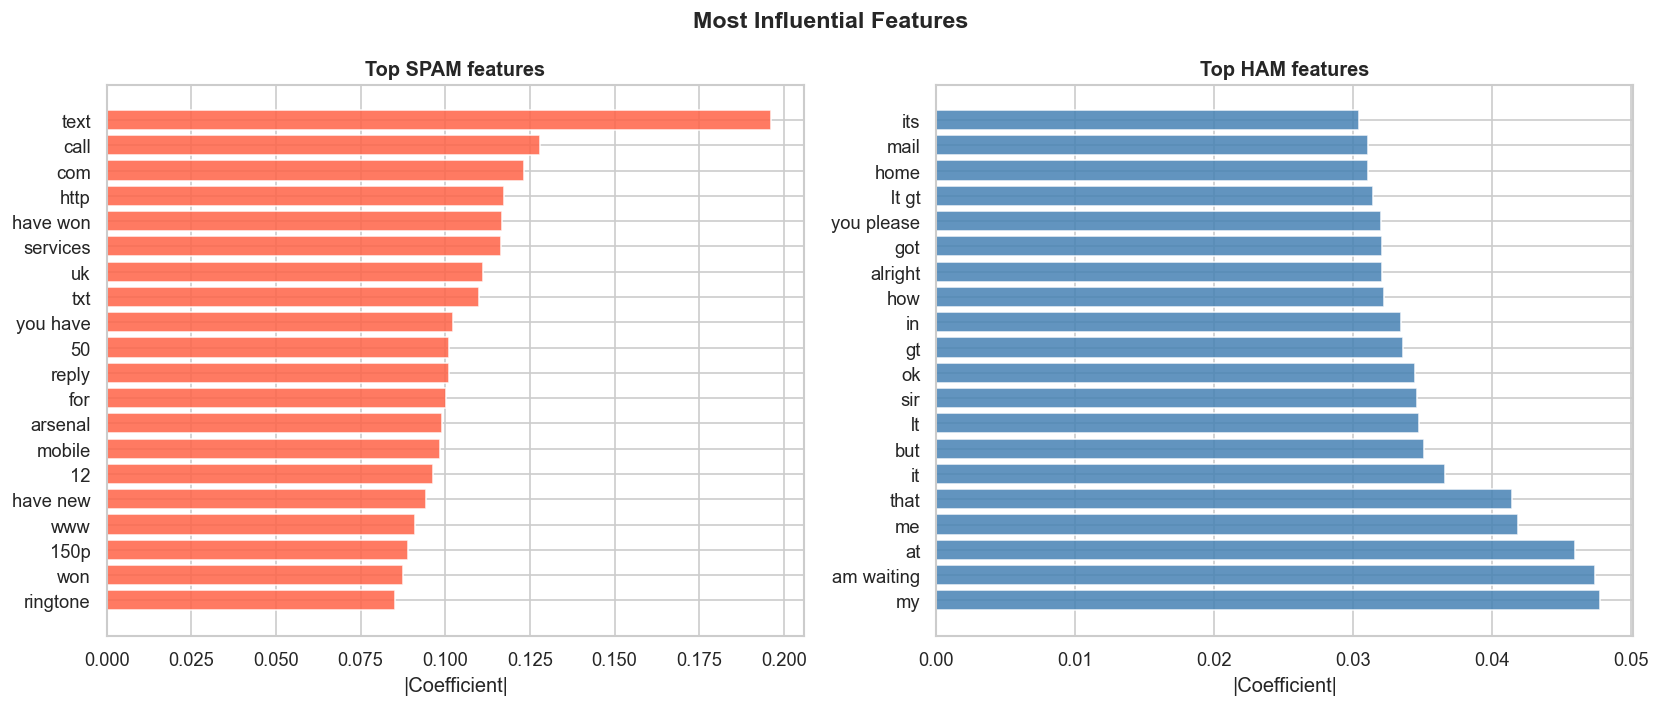

In [19]:
# ── Feature Importances (Random Forest / tree-based models) ──────────────────
if hasattr(best_model, 'feature_importances_'):
    feature_names = tfidf.get_feature_names_out()
    importances   = best_model.feature_importances_
    top_n = 20
    idx   = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), importances[idx][::-1],
            color='steelblue', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(feature_names[idx][::-1])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Most Important Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    # Logistic Regression / LinearSVC
    feature_names = tfidf.get_feature_names_out()
    coef = best_model.coef_.ravel()
    top_n = 20
    top_spam = np.argsort(coef)[::-1][:top_n]
    top_ham  = np.argsort(coef)[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(feature_names[top_spam][::-1], coef[top_spam][::-1],
                 color='tomato', alpha=0.85)
    axes[0].set_title('Top SPAM features', fontsize=12, fontweight='bold')
    axes[1].barh(feature_names[top_ham], np.abs(coef[top_ham]),
                 color='steelblue', alpha=0.85)
    axes[1].set_title('Top HAM features', fontsize=12, fontweight='bold')
    for ax in axes:
        ax.set_xlabel('|Coefficient|')
    plt.suptitle('Most Influential Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [20]:
# ── Save TF-IDF Vectorizer ───────────────────────────────────────────────────
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('✅ Saved: tfidf_vectorizer.pkl')

# ── Save Scaler ──────────────────────────────────────────────────────────────
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Saved: scaler.pkl')

# ── Save Best Model ──────────────────────────────────────────────────────────
model_filename = f'best_model_{best_model_name.lower().replace(" ", "_")}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f'✅ Saved: {model_filename}')

# ── Save Label Encoder ───────────────────────────────────────────────────────
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✅ Saved: label_encoder.pkl')

✅ Saved: tfidf_vectorizer.pkl
✅ Saved: scaler.pkl
✅ Saved: best_model_logistic_regression.pkl
✅ Saved: label_encoder.pkl


In [21]:
# ── Verify: Load & Predict ───────────────────────────────────────────────────
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

def predict_spam(messages):
    """Predict spam/ham for a list of messages."""
    X_vec  = loaded_tfidf.transform(messages)
    # Skip scaler for Naive Bayes
    if best_model_name != 'Naive Bayes':
        X_vec = loaded_scaler.transform(X_vec)
    preds = loaded_model.predict(X_vec)
    return loaded_le.inverse_transform(preds)

# Test predictions
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here NOW to claim your prize!",
    "Hey, are you coming to the meeting at 3pm?",
    "URGENT: Your account has been suspended. Verify immediately at http://scam.com",
    "I'll be home late tonight, can you start dinner?",
]

print('Prediction Test:')
print('-' * 70)
for msg, pred in zip(test_messages, predict_spam(test_messages)):
    emoji = '🚫' if pred == 'spam' else '✅'
    print(f'{emoji} [{pred.upper():>4}] {msg[:60]}')

Prediction Test:
----------------------------------------------------------------------
🚫 [SPAM] Congratulations! You've won a FREE iPhone. Click here NOW to
✅ [ HAM] Hey, are you coming to the meeting at 3pm?
🚫 [SPAM] URGENT: Your account has been suspended. Verify immediately 
✅ [ HAM] I'll be home late tonight, can you start dinner?
